# Task 6 — Complete Machine-Learning Workflow with Scikit-learn

**Topics:** Scikit-learn workflow and pipelines; K-Means, Hierarchical Clustering, and DBSCAN.



## 1. Setup and Dataset Upload

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())


Saving task6_wine_dataset.csv to task6_wine_dataset.csv
Dataset shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,target,alcohol_level
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,High
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Medium
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Medium
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,High
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Medium


## 2. Initial Exploration

In [2]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nTarget distribution:")
display(df["target"].value_counts().sort_index())


Data types:


,dtype
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64



Missing values:


,missing_values
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Target distribution:


,count
target,
0,59
1,71
2,48


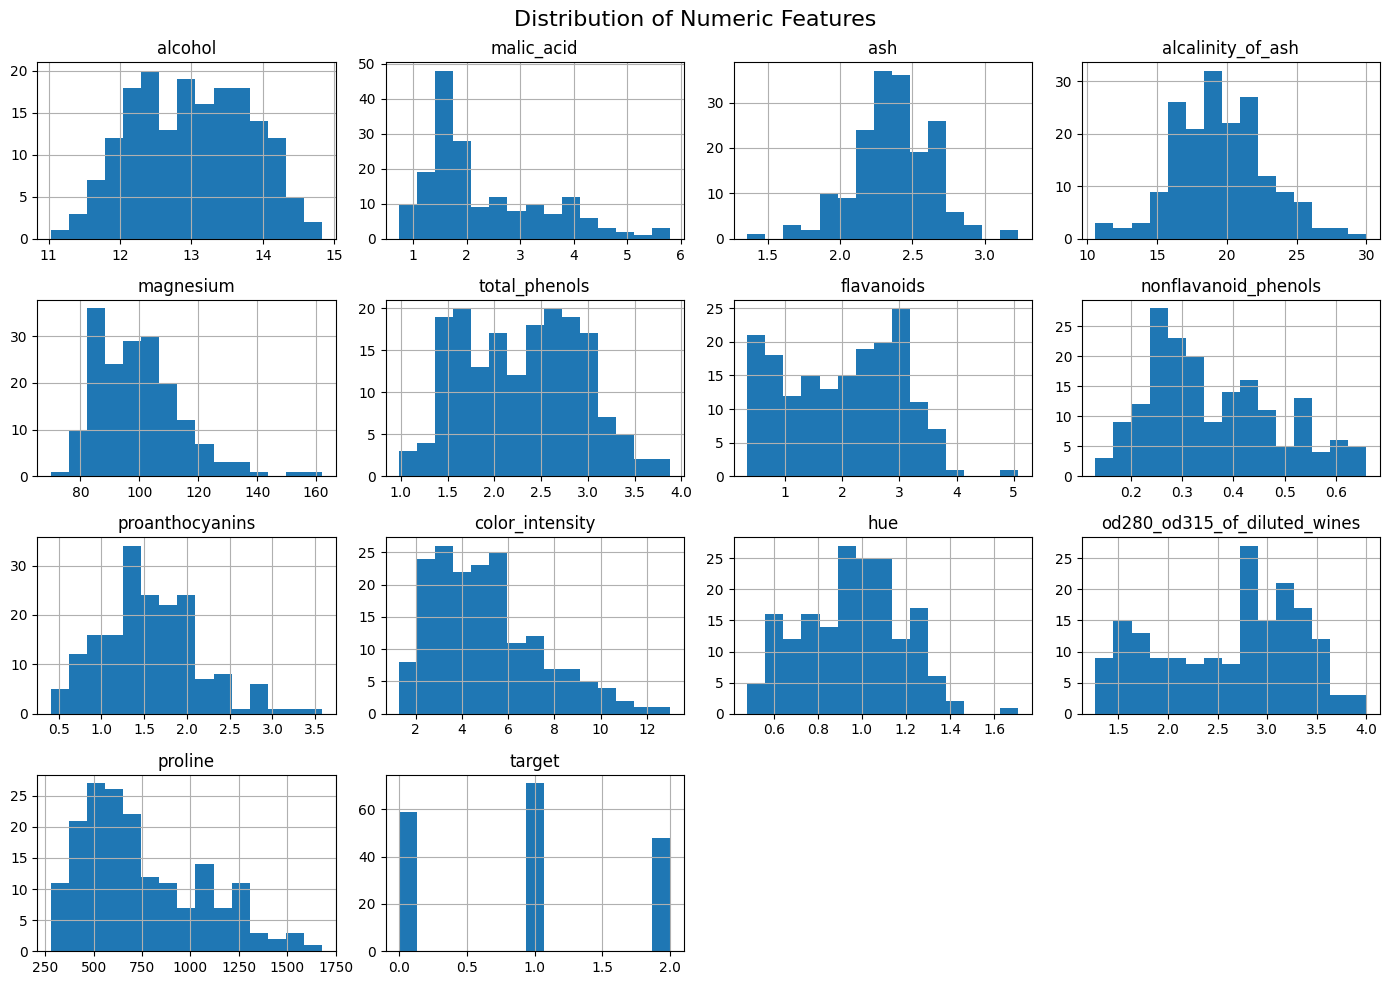

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


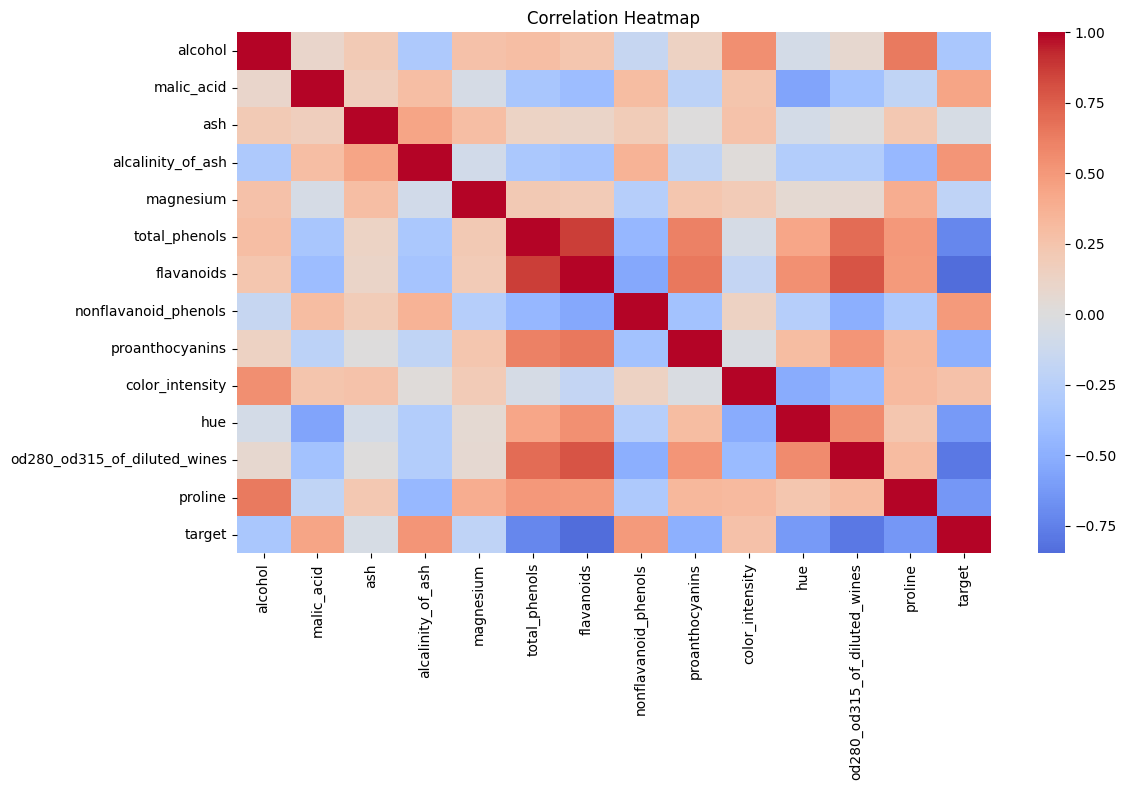

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Quick interpretation
The heatmap helps identify correlated numeric features, while the distributions show the scale and spread of the variables. This is useful before selecting preprocessing and modeling steps.

## 3. Preprocessing and Train/Test Split

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


X = df.drop(columns="target")
y = df["target"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 142
Testing samples : 36


## 4. Scikit-learn Pipeline and Model Building

In [9]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("Pipeline trained successfully.")


Pipeline trained successfully.


## 5. Model Evaluation

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})
display(metrics.round(3))
print(classification_report(y_test, y_pred, zero_division=0))


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



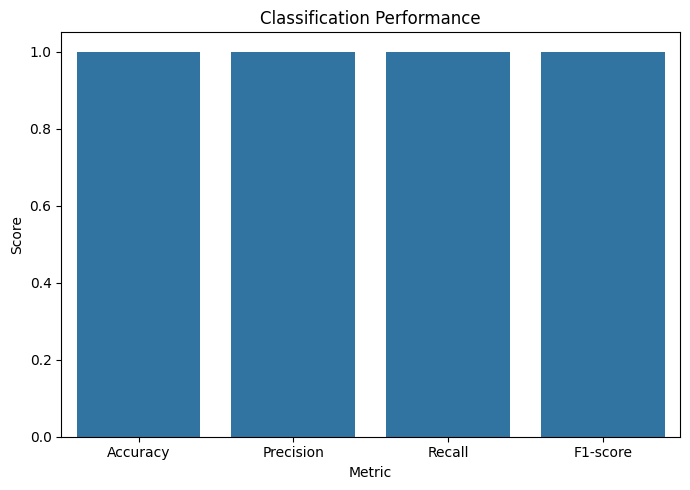

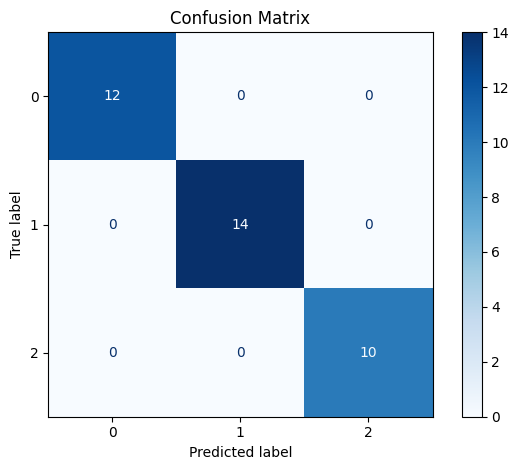

In [11]:
plt.figure(figsize=(7, 5))
sns.barplot(data=metrics, x="Metric", y="Score")
plt.ylim(0, 1.05)
plt.title("Classification Performance")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


### Model interpretation
The pipeline keeps preprocessing and modeling together, reducing the risk of inconsistent transformations. The confusion matrix shows correct and incorrect predictions for each class, while accuracy, precision, recall, and F1-score summarize performance.

## 6. Prepare Data for Clustering

In [13]:
cluster_features = [c for c in numeric_features if c != "target"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

print("Features used for clustering:", cluster_features)
print("Clustering matrix shape:", X_cluster.shape)


Features used for clustering: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315_of_diluted_wines', 'proline']
Clustering matrix shape: (178, 13)


## 7. K-Means Clustering

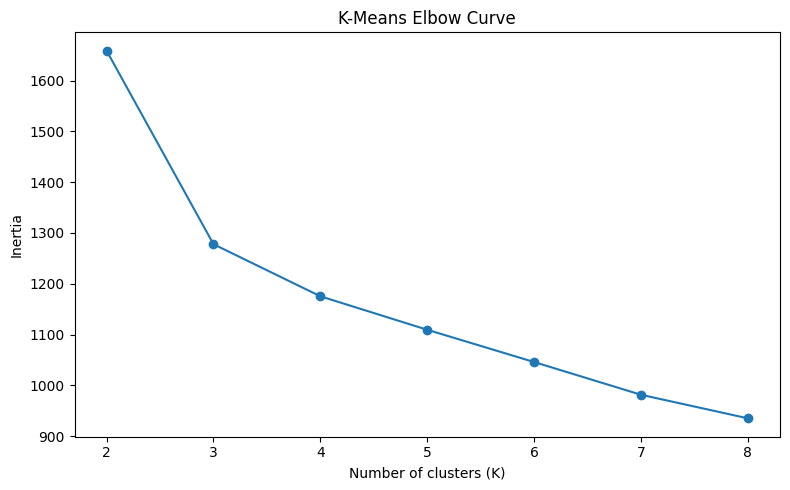

In [14]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


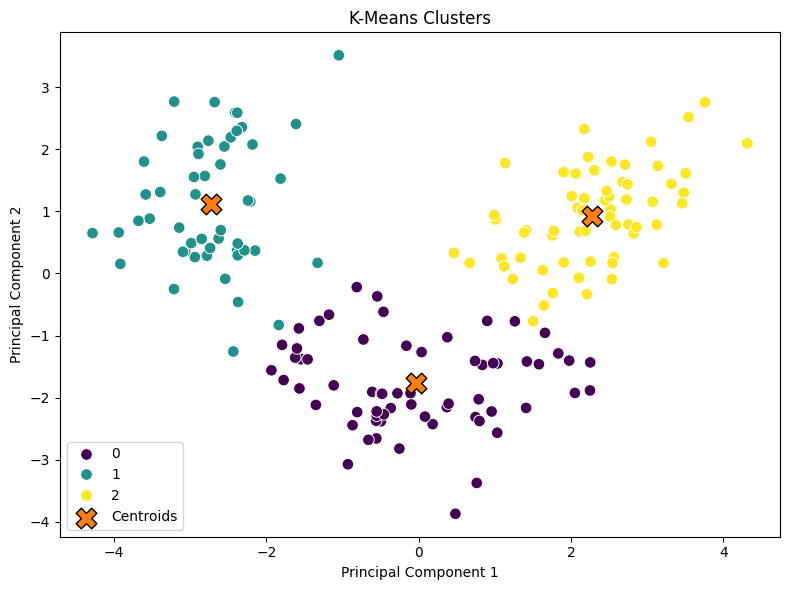

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

pca = __import__("sklearn.decomposition", fromlist=["PCA"]).PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="viridis", s=70)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=220, edgecolor="black", label="Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The elbow curve helps choose a practical K by looking for diminishing improvement in inertia. The PCA plot gives a 2D view of the resulting clusters; the X markers are the cluster centroids.

## 8. Hierarchical Clustering

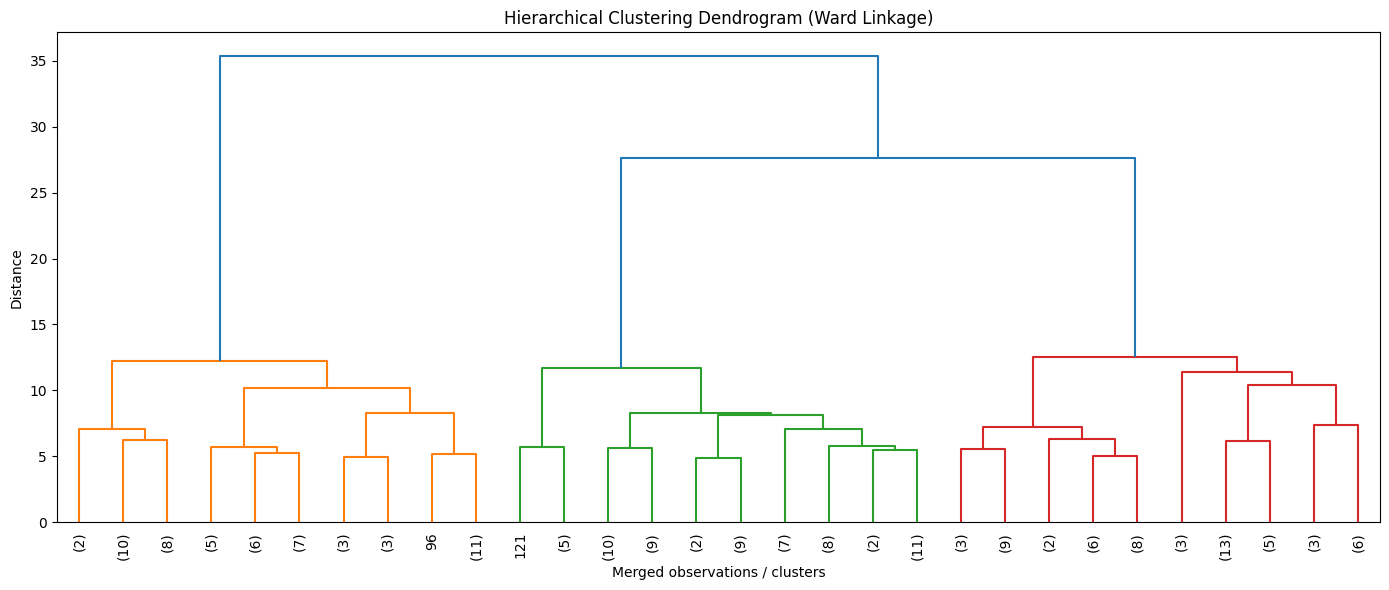

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Merged observations / clusters")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


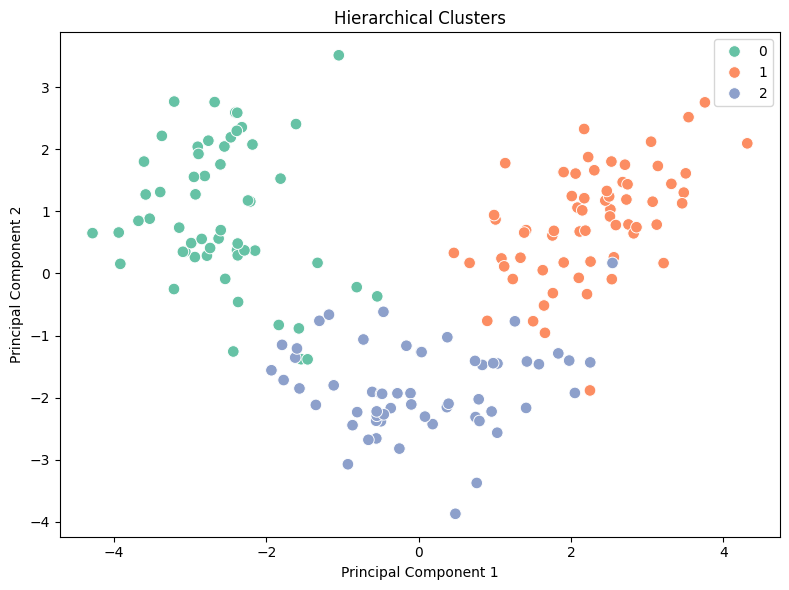

In [17]:
hier_labels = fcluster(Z, t=3, criterion="maxclust") - 1

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hier_labels, palette="Set2", s=70)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters")
plt.tight_layout()
plt.show()


**Interpretation:** Hierarchical clustering builds nested groups. The dendrogram shows how observations/clusters merge at increasing distances; cutting the hierarchy into three groups produces the displayed cluster assignments.

## 9. DBSCAN Clustering

In [18]:
from sklearn.cluster import DBSCAN

# Try a small range of eps values to observe the effect.
eps_values = [0.8, 1.0, 1.2, 1.4]
dbscan_results = []

for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    dbscan_results.append([eps, n_clusters, n_noise])

dbscan_summary = pd.DataFrame(dbscan_results, columns=["eps", "clusters", "noise_points"])
display(dbscan_summary)


,eps,clusters,noise_points
0,0.8,0,178
1,1.0,0,178
2,1.2,0,178
3,1.4,0,178


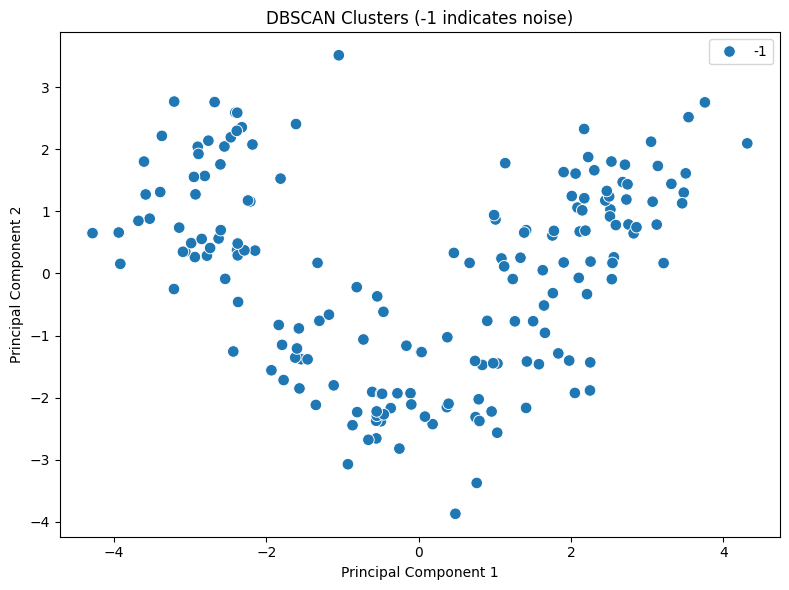

In [19]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
db_labels = dbscan.fit_predict(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=db_labels, palette="tab10", s=70
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters (-1 indicates noise)")
plt.tight_layout()
plt.show()


**Interpretation:** DBSCAN groups dense regions and labels points that do not belong to a sufficiently dense neighborhood as noise (`-1`). Unlike K-Means, it does not require the number of clusters to be specified in advance.

## 10. Clustering Evaluation

In [20]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

def clustering_metrics(X, labels, name):
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]
    if len(np.unique(labels_eval)) < 2:
        return [name, np.nan, np.nan, np.nan]
    return [
        name,
        silhouette_score(X_eval, labels_eval),
        davies_bouldin_score(X_eval, labels_eval),
        calinski_harabasz_score(X_eval, labels_eval)
    ]

results = pd.DataFrame([
    clustering_metrics(X_cluster, kmeans_labels, "K-Means"),
    clustering_metrics(X_cluster, hier_labels, "Hierarchical"),
    clustering_metrics(X_cluster, db_labels, "DBSCAN")
], columns=["Algorithm", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"])

display(results.round(3))


,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.285,1.389,70.940
1,Hierarchical,0.277,1.419,67.647
2,DBSCAN,NaN,NaN,NaN


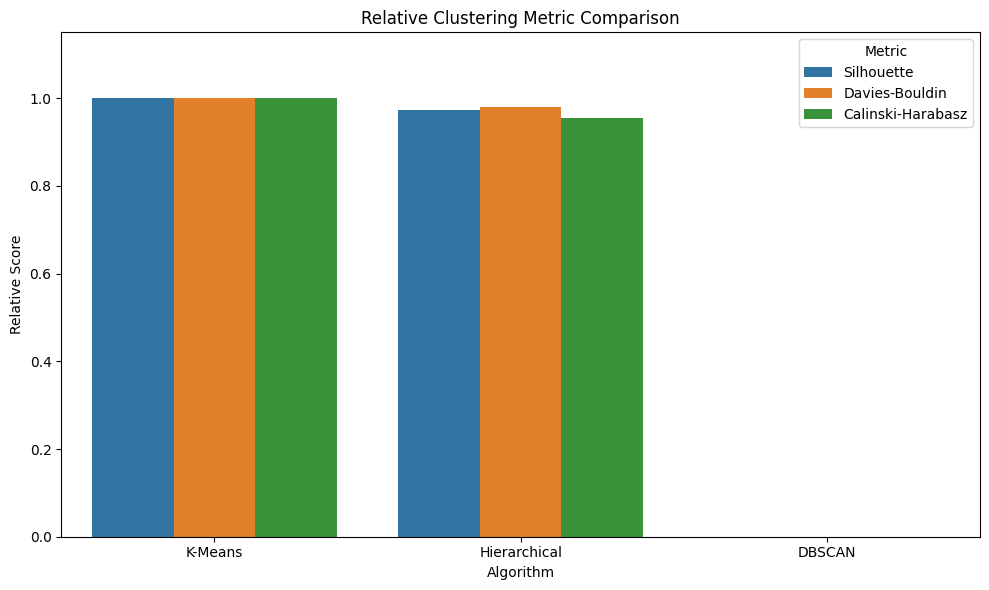

In [21]:
# Compare the clustering algorithms using normalized metric values for easier visual comparison.
comparison = results.copy()
comparison["Silhouette"] = comparison["Silhouette"] / comparison["Silhouette"].max()
comparison["Calinski-Harabasz"] = comparison["Calinski-Harabasz"] / comparison["Calinski-Harabasz"].max()
comparison["Davies-Bouldin"] = comparison["Davies-Bouldin"].min() / comparison["Davies-Bouldin"]

plot_df = comparison.melt(
    id_vars="Algorithm",
    var_name="Metric",
    value_name="Relative Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Algorithm", y="Relative Score", hue="Metric")
plt.ylim(0, 1.15)
plt.title("Relative Clustering Metric Comparison")
plt.tight_layout()
plt.show()



- **Silhouette Score:** higher is generally better; it measures separation and cohesion.
- **Davies-Bouldin Index:** lower is better; it penalizes clusters that are too similar or poorly separated.
- **Calinski-Harabasz Score:** higher is generally better; it compares between-cluster separation with within-cluster compactness.



## 11. Cluster Profiling and Interpretation

In [22]:
profile = df[cluster_features].copy()
profile["KMeans_Cluster"] = kmeans_labels
cluster_profile = profile.groupby("KMeans_Cluster")[cluster_features].mean().round(2)

display(cluster_profile)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
KMeans_Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


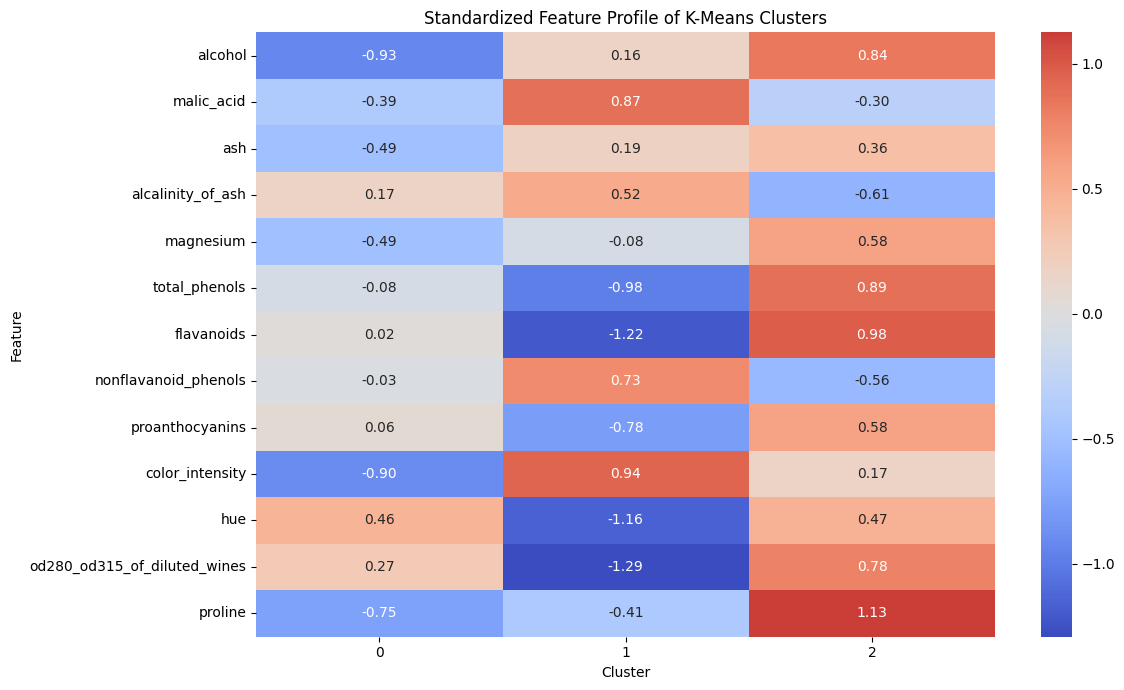

In [24]:
profile_scaled = pd.DataFrame(X_cluster, columns=cluster_features)
profile_scaled["Cluster"] = kmeans_labels
mean_scaled = profile_scaled.groupby("Cluster").mean().T

plt.figure(figsize=(12, 7))
sns.heatmap(mean_scaled, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Standardized Feature Profile of K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 12. Final Conclusion

The notebook demonstrated a complete Scikit-learn workflow using preprocessing, a reusable pipeline, model training, evaluation, and interpretation. For unsupervised learning, K-Means, Hierarchical Clustering, and DBSCAN were implemented and compared using visualizations and clustering metrics. The combination of metric scores and visual inspection gives a stronger basis for selecting an appropriate clustering method.